In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay
)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_parquet(PROCESSED_DIR / "train_events_v1.parquet")
valid = pd.read_parquet(PROCESSED_DIR / "validation_events_v1.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test_events_v1.parquet")

feature_columns = pd.read_csv(
    PROCESSED_DIR / "feature_list_v1.csv"
)["feature_name"].tolist()

TARGET = "reversal"
CATEGORICAL_FEATURES = ["sector"]
NUMERIC_FEATURES = feature_columns
MODEL_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

FINAL_THRESHOLD = 0.40

print("Train rows:", len(train))
print("Validation rows:", len(valid))
print("Test rows:", len(test))
print("Final threshold:", FINAL_THRESHOLD)

Train rows: 11288
Validation rows: 1771
Test rows: 1785
Final threshold: 0.4


In [2]:
train_valid = pd.concat(
    [train, valid],
    ignore_index=True
).sort_values(["Date", "ticker"]).reset_index(drop=True)

X_train_valid = train_valid[MODEL_COLUMNS].copy()
y_train_valid = train_valid[TARGET].copy()

X_test = test[MODEL_COLUMNS].copy()
y_test = test[TARGET].copy()

print("Train + validation shape:", X_train_valid.shape)
print("Test shape:", X_test.shape)

print("\nTrain + validation reversal rate:")
print(round(y_train_valid.mean() * 100, 2), "%")

print("\nTest reversal rate:")
print(round(y_test.mean() * 100, 2), "%")

Train + validation shape: (13059, 23)
Test shape: (1785, 23)

Train + validation reversal rate:
26.24 %

Test reversal rate:
21.68 %


In [3]:
numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, NUMERIC_FEATURES),
        ("categorical", categorical_preprocessor, CATEGORICAL_FEATURES)
    ]
)

final_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=400,
            max_depth=8,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

final_rf_pipeline.fit(X_train_valid, y_train_valid)

print("Final Random Forest trained on train + validation.")

Final Random Forest trained on train + validation.


In [4]:
test_probabilities = final_rf_pipeline.predict_proba(X_test)[:, 1]
test_predictions = (
    test_probabilities >= FINAL_THRESHOLD
).astype(int)

final_test_results = pd.DataFrame([{
    "model": "Random Forest",
    "train_period": "2015-02-19 to 2024-12-23",
    "test_period": "2025-01-01 to 2026-06-12",
    "threshold": FINAL_THRESHOLD,
    "test_rows": len(y_test),
    "test_reversal_rate": round(y_test.mean(), 4),
    "accuracy": round(accuracy_score(y_test, test_predictions), 4),
    "precision": round(
        precision_score(y_test, test_predictions, zero_division=0),
        4
    ),
    "recall": round(
        recall_score(y_test, test_predictions, zero_division=0),
        4
    ),
    "f1": round(
        f1_score(y_test, test_predictions, zero_division=0),
        4
    ),
    "roc_auc": round(
        roc_auc_score(y_test, test_probabilities),
        4
    ),
    "pr_auc": round(
        average_precision_score(y_test, test_probabilities),
        4
    ),
    "predicted_reversals": int(test_predictions.sum())
}])

final_test_results

,model,train_period,test_period,threshold,test_rows,test_reversal_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,predicted_reversals
0,Random Forest,2015-02-19 to 2024-12-23,2025-01-01 to 2026-06-12,0.4,1785,0.2168,0.5294,0.2441,0.5581,0.3396,0.5545,0.2792,885


              precision    recall  f1-score   support

 No reversal       0.81      0.52      0.63      1398
    Reversal       0.24      0.56      0.34       387

    accuracy                           0.53      1785
   macro avg       0.53      0.54      0.49      1785
weighted avg       0.69      0.53      0.57      1785

Confusion matrix:
[[729 669]
 [171 216]]


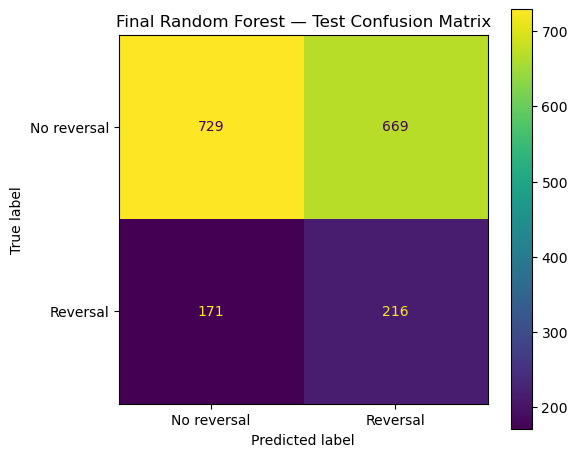

In [5]:
print(classification_report(
    y_test,
    test_predictions,
    target_names=["No reversal", "Reversal"],
    zero_division=0
))

cm = confusion_matrix(y_test, test_predictions)

print("Confusion matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No reversal", "Reversal"]
).plot(ax=ax, values_format="d")

ax.set_title("Final Random Forest — Test Confusion Matrix")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "final_test_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

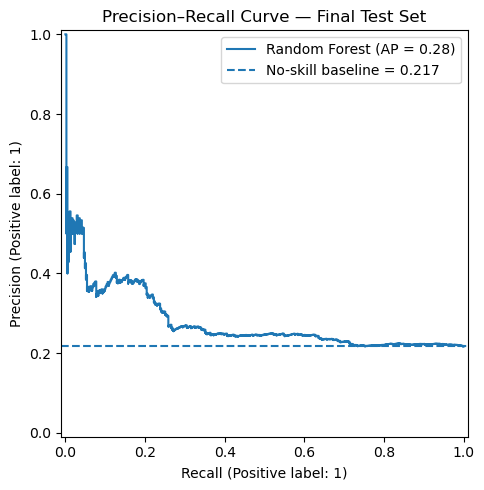

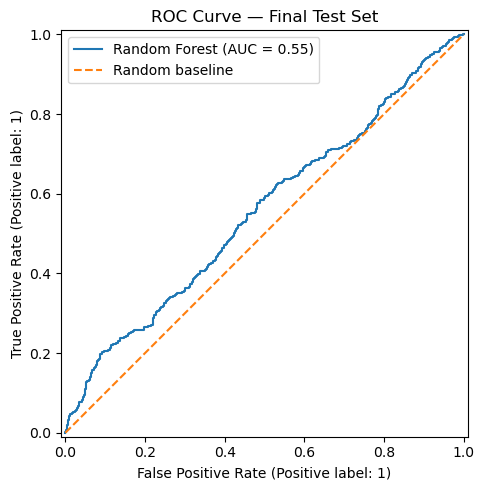

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities,
    ax=ax,
    name="Random Forest"
)

ax.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"No-skill baseline = {y_test.mean():.3f}"
)

ax.set_title("Precision–Recall Curve — Final Test Set")
ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "final_test_precision_recall_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities,
    ax=ax,
    name="Random Forest"
)

ax.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")

ax.set_title("ROC Curve — Final Test Set")
ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "final_test_roc_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [7]:
fitted_preprocessor = final_rf_pipeline.named_steps["preprocessor"]
fitted_rf = final_rf_pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": fitted_rf.feature_importances_
})

feature_importance["feature"] = (
    feature_importance["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__sector_", "sector_", regex=False)
)

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(15)

,feature,importance
0,atr_pct_14,0.107691
1,nifty_volatility_10d,0.092305
2,nifty_return_5d,0.073242
3,nifty_return_20d,0.060251
4,nifty_return_10d,0.059515
5,spectral_norm_10d,0.045311
6,rolling_volatility_10d,0.044863
7,bollinger_width,0.039433
8,macd_histogram,0.038937
9,price_velocity_5d,0.038233


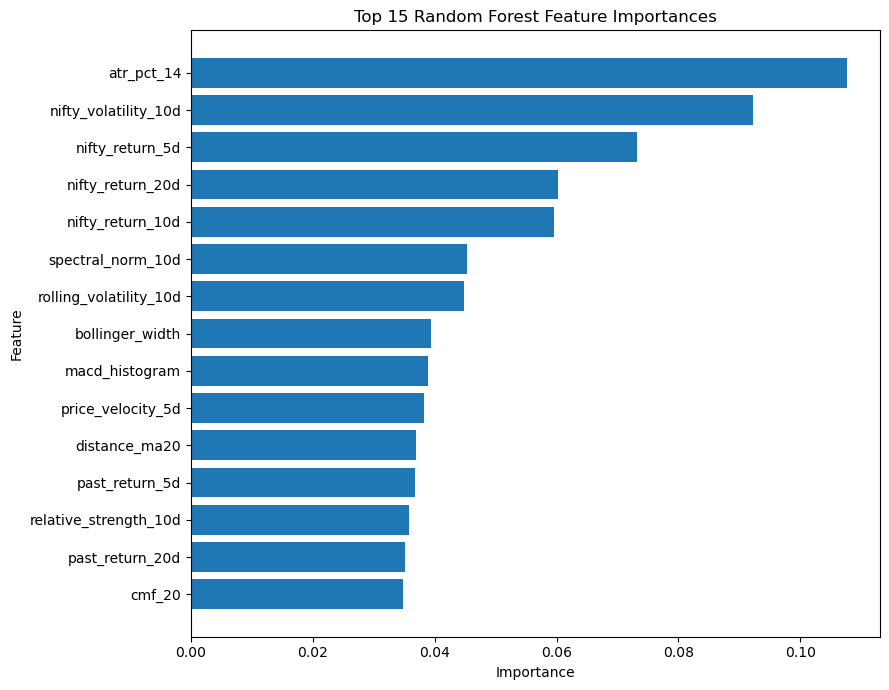

In [8]:
top_features = feature_importance.head(15).sort_values(
    "importance",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    top_features["feature"],
    top_features["importance"]
)

ax.set_title("Top 15 Random Forest Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "final_feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [9]:
import joblib

joblib.dump(
    final_rf_pipeline,
    MODELS_DIR / "random_forest_reversal_model_v1.joblib"
)

final_test_results.to_csv(
    PROCESSED_DIR / "final_test_results_v1.csv",
    index=False
)

feature_importance.to_csv(
    PROCESSED_DIR / "final_feature_importance_v1.csv",
    index=False
)

print("Saved model:")
print(MODELS_DIR / "random_forest_reversal_model_v1.joblib")

print("\nSaved results:")
print(PROCESSED_DIR / "final_test_results_v1.csv")
print(PROCESSED_DIR / "final_feature_importance_v1.csv")

print("\nSaved figures:")
print(FIGURES_DIR)

Saved model:
/Users/kartiksinghai/Desktop/nse-stock-reversal-predictor/models/random_forest_reversal_model_v1.joblib

Saved results:
/Users/kartiksinghai/Desktop/nse-stock-reversal-predictor/data/processed/final_test_results_v1.csv
/Users/kartiksinghai/Desktop/nse-stock-reversal-predictor/data/processed/final_feature_importance_v1.csv

Saved figures:
/Users/kartiksinghai/Desktop/nse-stock-reversal-predictor/reports/figures


In [13]:
import joblib

MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    final_rf_pipeline,
    MODELS_DIR / "random_forest_reversal_model.joblib"
)

joblib.dump(
    MODEL_COLUMNS,
    MODELS_DIR / "feature_columns.joblib"
)

joblib.dump(
    FINAL_THRESHOLD,
    MODELS_DIR / "decision_threshold.joblib"
)

print("Final model artifacts saved successfully.")

Final model artifacts saved successfully.


In [14]:
list(MODELS_DIR.iterdir())

[PosixPath('/Users/kartiksinghai/Desktop/nse-stock-reversal-predictor/models/decision_threshold.joblib'),
 PosixPath('/Users/kartiksinghai/Desktop/nse-stock-reversal-predictor/models/random_forest_reversal_model_v1.joblib'),
 PosixPath('/Users/kartiksinghai/Desktop/nse-stock-reversal-predictor/models/feature_columns.joblib'),
 PosixPath('/Users/kartiksinghai/Desktop/nse-stock-reversal-predictor/models/random_forest_reversal_model.joblib')]

In [15]:
for file in MODELS_DIR.iterdir():
    size_mb = file.stat().st_size / (1024 * 1024)
    print(f"{file.name}: {size_mb:.2f} MB")

decision_threshold.joblib: 0.00 MB
random_forest_reversal_model_v1.joblib: 7.39 MB
feature_columns.joblib: 0.00 MB
random_forest_reversal_model.joblib: 7.39 MB
